In [1]:
import torch
import CT.Models.misc as misc
import CT.Inference.TLQG.performance as performance
from tqdm import tqdm
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

lag_ratio = 1
LSDM_QG_file_path = "/scratch/ql2221/CT_models/wandb_data/wandb/run-20260119_122954-1cxsh1jy/files/checkpoint_last.p"

LSDM_QG = misc.load_LSDM(LSDM_QG_file_path).to(device)

/ext3/miniforge3/lib/python3.12/site-packages/CT/Models/misc.py:94: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_dict = torch.load(file_string)


In [2]:
#load data
data_dict = torch.load("/scratch/ql2221/PDE_data/2LQG/jet/qg_jet_long_ICML_NUM.pt")
data = data_dict["data"]
print(data.shape)

/state/partition1/job-2666244/ipykernel_1259845/54506242.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data_dict = torch.load("/scratch/ql2221/PDE_data/2LQG/jet/qg_jet

torch.Size([20, 50000, 2, 64, 64])


In [3]:
upper_std=7.6382e-06
lower_std=3.0120e-07
data[:,:,0,:,:]/=upper_std
data[:,:,1,:,:]/=lower_std

In [6]:
x = data[0:1].to(device)
x_t = x[:,-1]
short_lag = torch.tensor([1]).to(device)
long_lag = torch.tensor([99]).to(device)
x_short = x[:,-(1 * lag_ratio)-1].to(device)
x_long = x[:,-(99 * lag_ratio)-1].to(device)
s_short = 20
x_short = LSDM_QG._forward_diffusion(x_short, s_short).to(device)
s_t = 900
x_t_noised = LSDM_QG._forward_diffusion(x_t, s_t).to(device)
x_in = torch.cat((x_long.unsqueeze(1), x_short.unsqueeze(1), x_t_noised.unsqueeze(1)),dim = 1)
print(x_short.shape)
print(x_t.shape)
print(x_long.shape)
x_for_classifier = torch.cat((x_long, x_short, x_t_noised),dim = 1)
pred_s = LSDM_QG.model.ratio_class_both(x_for_classifier, None, None, long_lag).to(device)
denoised = LSDM_QG.denoising_left_down(x_in, long_lag, pred_s, forward_diff = False)

torch.Size([1, 2, 64, 64])
torch.Size([1, 2, 64, 64])
torch.Size([1, 2, 64, 64])


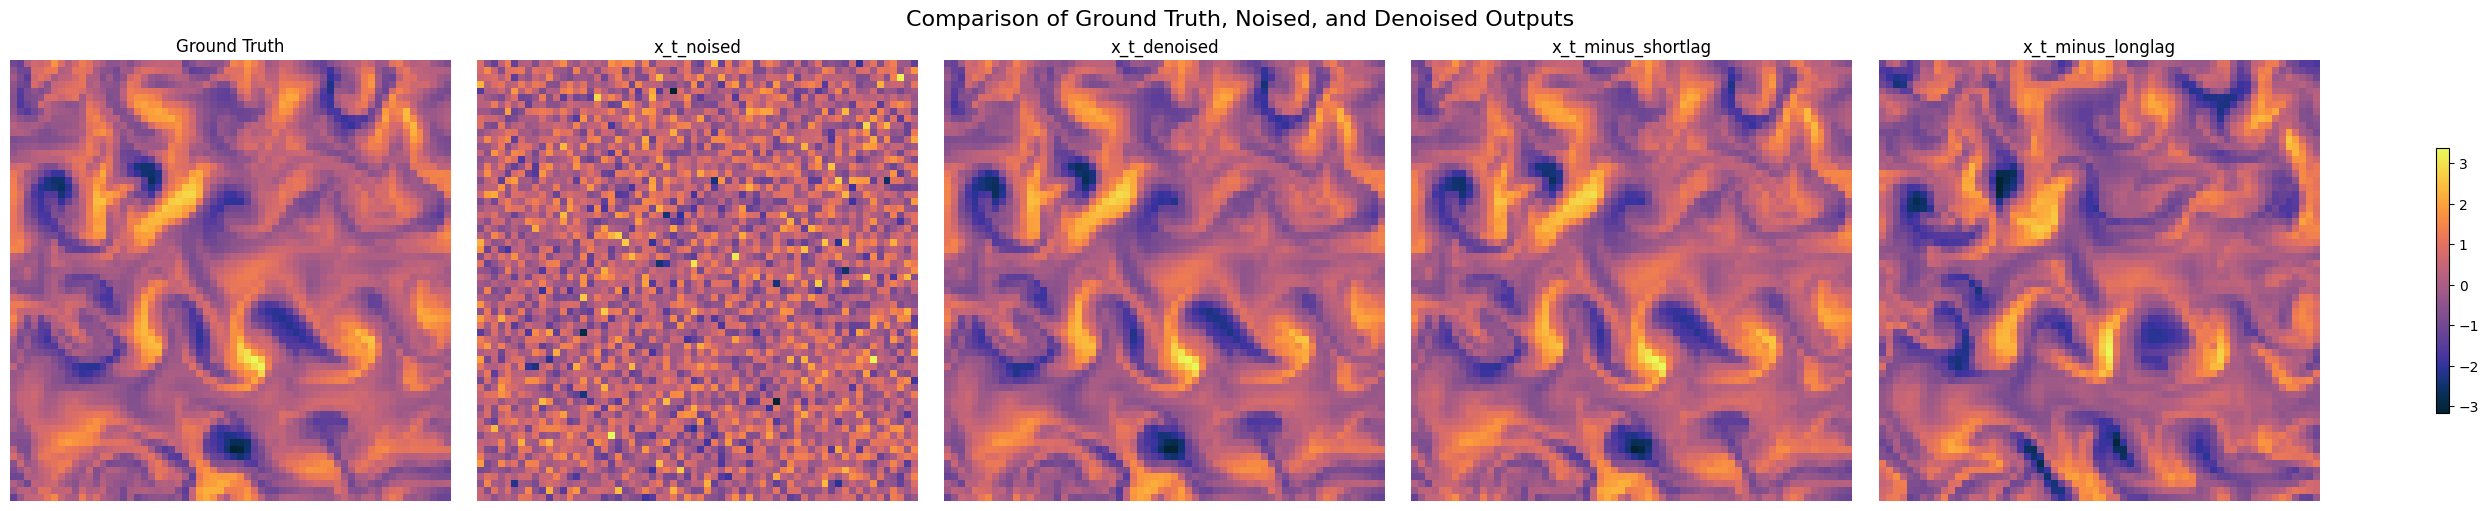

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import cmocean

tensors = [
    x_t[:,-1:],                
    x_t_noised[:,-1:],
    denoised[:,-1,-1],
    x_short[:,-1:],
    x_long[:,-1:]
]
titles = [
    'Ground Truth',
    'x_t_noised',
    'x_t_denoised',
    'x_t_minus_shortlag',
    'x_t_minus_longlag'
]

# make the figure
fig, axes = plt.subplots(1, len(tensors), figsize=(25, 5), constrained_layout=True)

for ax, tensor, title in zip(axes, tensors, titles):
    # squeeze to (H, W)
    tensor_np = tensor.squeeze().detach().cpu().numpy()
    im = ax.imshow(tensor_np, cmap=cmocean.cm.thermal)
    ax.set_title(title, fontsize=12)
    ax.axis('off')

# add colorbar across all axes
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6)
fig.suptitle(r'Comparison of Ground Truth, Noised, and Denoised Outputs', fontsize=16)

plt.savefig("comparison_diffusion.png", dpi=300, bbox_inches='tight')
plt.show()


In [4]:
x = data.to(device)
Emu_file_path = file_string = "/scratch/ql2221/thermalizer_data/wandb_data/wandb/run-20260128_025723-qbx6gf4w/files/checkpoint_best.p"
Emu = misc.load_Emulator(Emu_file_path).to(device)
Emu.eval()
# LSDM_QG.model.eval()
# rollout= performance.LSDM_QG_inference(data[:,0:1], Emu, LSDM_QG, n_steps=50000, short_lag_int = 1, freq = lag_ratio, lag_ratio = lag_ratio, s_init = -1, max_long_lag = 99, starting_time = 100, sigma=None, silence=False, forward_diff = True, denoise_mode = "left_down", device = "cuda")

/ext3/miniforge3/lib/python3.12/site-packages/CT/Models/misc.py:87: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_dict = torch.load(file_string)


ModernUnet(
  (activation): GELU(approximate='none')
  (image_proj): Conv2d(2, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=circular)
  (down): ModuleList(
    (0): Down_block(
      (res): Residual_block(
        (activation): GELU(approximate='none')
        (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=circular)
        (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=circular)
        (shortcut): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), padding_mode=circular)
        (norm1): Identity()
        (norm2): Identity()
      )
      (attn): Identity()
    )
    (1): Down_block(
      (res): Residual_block(
        (activation): GELU(approximate='none')
        (conv1): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=circular)
        (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), padding_mode=circular)
       

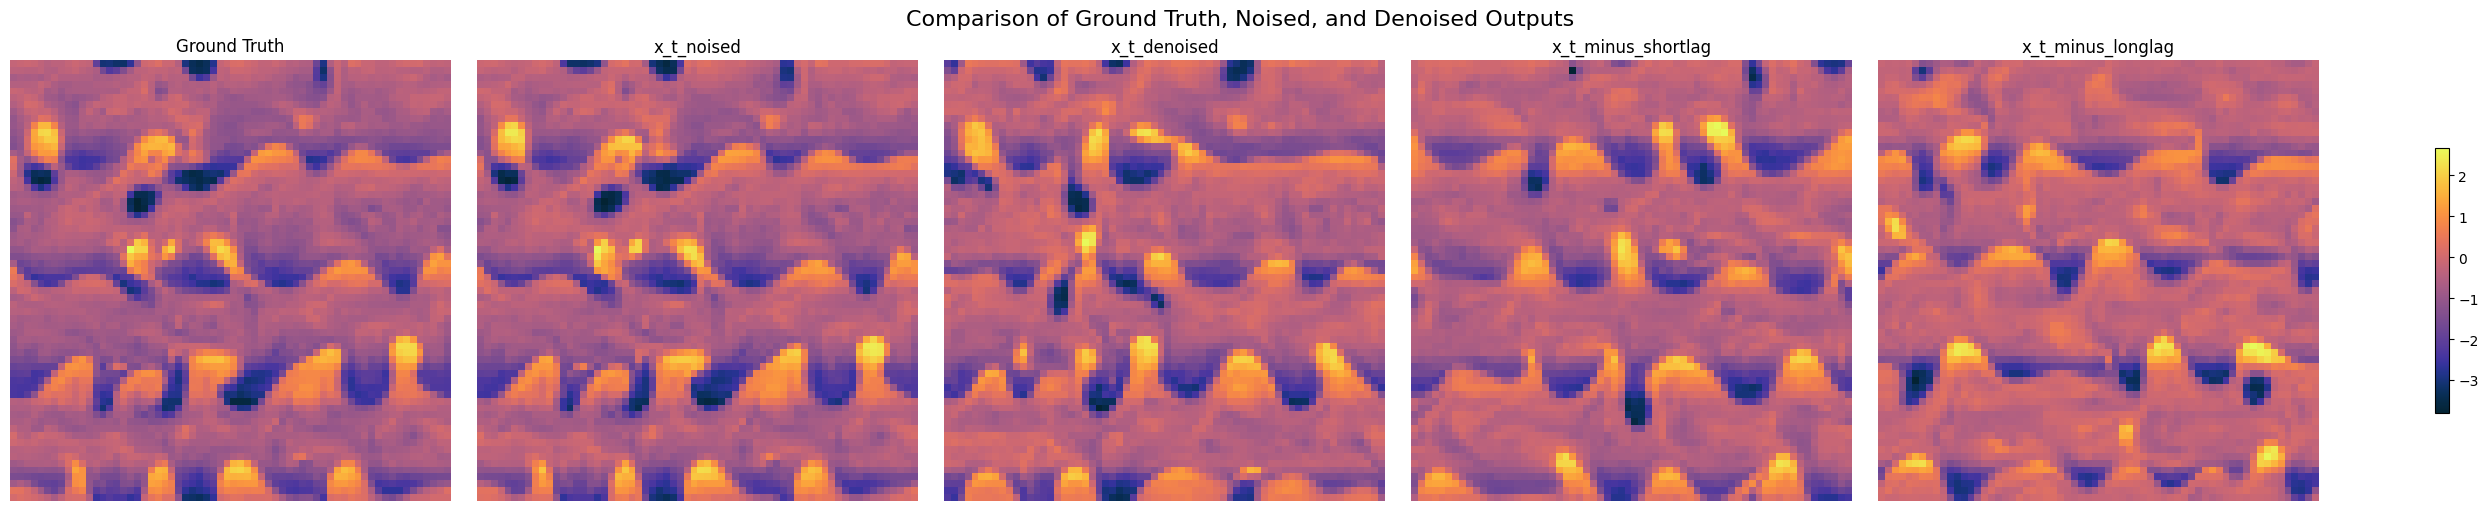

In [13]:
import matplotlib.pyplot as plt
import numpy as np
import cmocean

T = 30000
B = 0
tensors = [
    rollout[B:B+1,T-1,-2:-1],                
    rollout[B:B+1,T-10,-2:-1],
    rollout[B:B+1,T-100,-2:-1],
    rollout[B:B+1,T-1000,-2:-1],
    rollout[B:B+1,T-10000,-2:-1]
]
titles = [
    'Ground Truth',
    'x_t_noised',
    'x_t_denoised',
    'x_t_minus_shortlag',
    'x_t_minus_longlag'
]

# make the figure
fig, axes = plt.subplots(1, len(tensors), figsize=(25, 5), constrained_layout=True)

for ax, tensor, title in zip(axes, tensors, titles):
    # squeeze to (H, W)
    tensor_np = tensor.squeeze().detach().cpu().numpy()
    im = ax.imshow(tensor_np, cmap=cmocean.cm.thermal)
    ax.set_title(title, fontsize=12)
    ax.axis('off')

# add colorbar across all axes
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6)
fig.suptitle(r'Comparison of Ground Truth, Noised, and Denoised Outputs', fontsize=16)

# plt.savefig("comparison_diffusion.png", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
torch.save(rollout, "/scratch/ql2221/PDE_data/2LQG/jet/LSDM_inference_ICML.p")

In [5]:
x = data[:,0:1]
del data, data_dict
emu_rollout = performance.run_emu(x, emu = Emu, n_steps= 50000,silent=False,sigma=None)

100%|██████████| 49999/49999 [17:16<00:00, 48.24it/s]


In [7]:
torch.save(emu_rollout, "/scratch/ql2221/PDE_data/2LQG/jet/EMU_inference_ICML2026_formal.p")

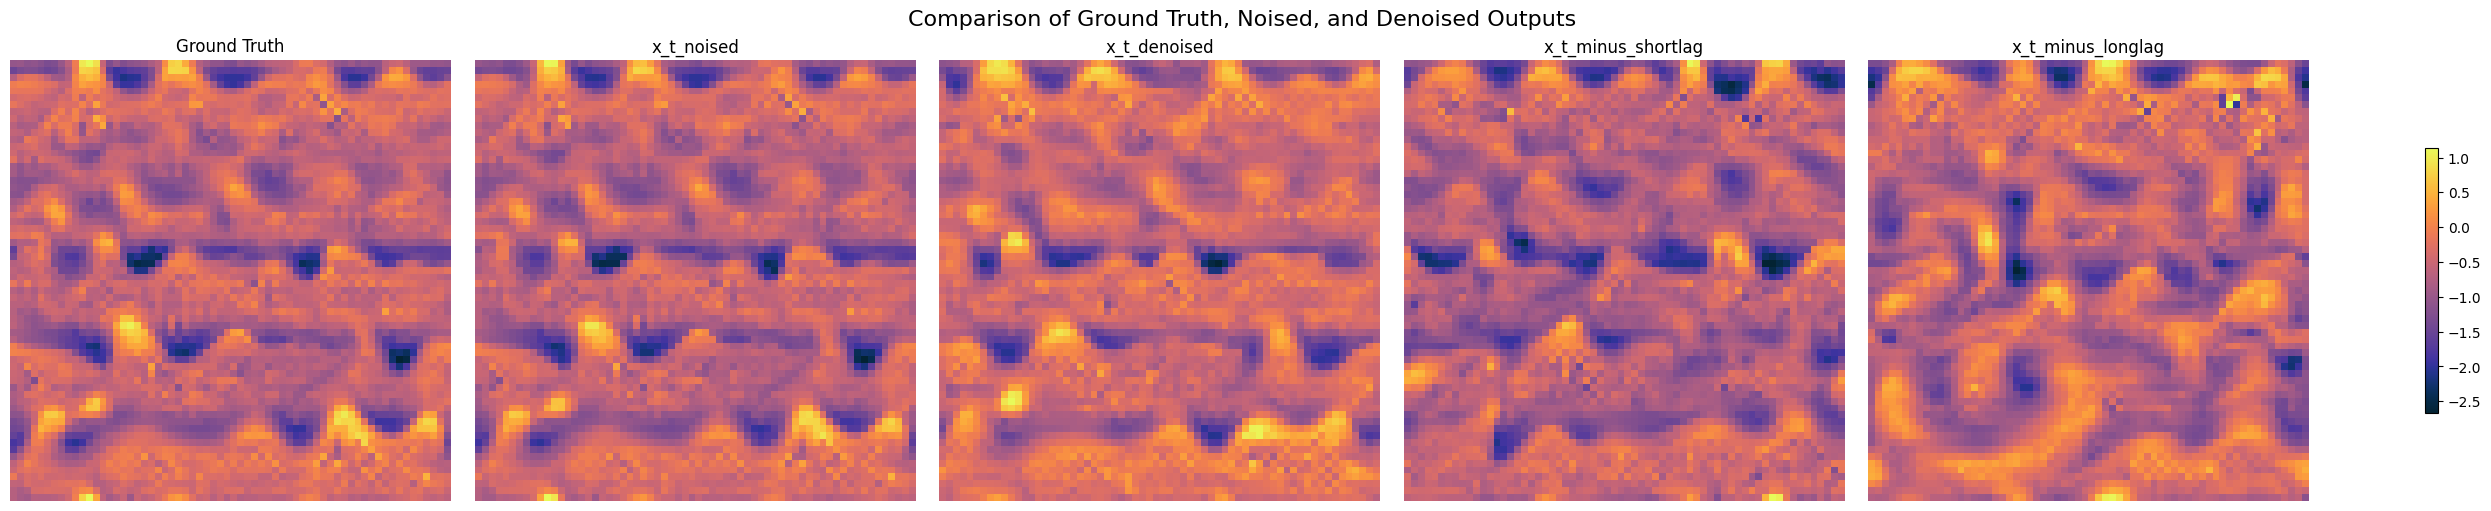

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import cmocean

T = 30000
B = 0

tensors = [
    emu_rollout[B:B+1,T-1,-2:-1],                
     emu_rollout[B:B+1,T-10,-2:-1],
     emu_rollout[B:B+1,T-100,-2:-1],
     emu_rollout[B:B+1,T-1000,-2:-1],
     emu_rollout[B:B+1,T-10000,-2:-1]
]
titles = [
    'Ground Truth',
    'x_t_noised',
    'x_t_denoised',
    'x_t_minus_shortlag',
    'x_t_minus_longlag'
]

# make the figure
fig, axes = plt.subplots(1, len(tensors), figsize=(25, 5), constrained_layout=True)

for ax, tensor, title in zip(axes, tensors, titles):
    # squeeze to (H, W)
    tensor_np = tensor.squeeze().detach().cpu().numpy()
    im = ax.imshow(tensor_np, cmap=cmocean.cm.thermal)
    ax.set_title(title, fontsize=12)
    ax.axis('off')

# add colorbar across all axes
fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.6)
fig.suptitle(r'Comparison of Ground Truth, Noised, and Denoised Outputs', fontsize=16)

# plt.savefig("comparison_diffusion.png", dpi=300, bbox_inches='tight')
plt.show()

In [12]:
# Make sure it's contiguous in memory for a safe view/reshape
x = data.contiguous()

# Group 20 -> 5 groups of 4, then flatten (4,10000) -> 40000 in the correct order
y = data.view(5, 4, 10000, 2, 64, 64).reshape(5, 40000, 2, 64, 64)

rollout = torch.load(
    "/scratch/ql2221/PDE_data/2LQG/jet/LSDM_inference.p",
    map_location="cpu"
)
tensor = torch.cat((y.to("cpu")[:,:30000],emu_rollout[0:5,0:30000].to("cpu"),rollout[0:5,0:30000].to("cpu")),dim = 0)

/state/partition1/job-1315350/ipykernel_4041079/4284633023.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  rollout = torch.load(


In [13]:
torch.save(tensor, "/scratch/ql2221/PDE_data/2LQG/jet/LSDM_inference_ICML2026_formal.p")

In [1]:
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

from moviepy.video.io.ffmpeg_writer import FFMPEG_VideoWriter
from tqdm import tqdm


def make_movie_moviepy_qg_6x5(
    state_vector,
    save_path="qg_6x5_movie.mp4",
    fps=30,
    vmin=None,
    vmax=None,
    stride=10,
    col_titles=None,          # len 5 (column titles)
    method_names=("Numerical", "Gaussian", "SNS refined"),
    layer_names=("Top", "Bottom"),
    cmap="viridis",
    interpolation="nearest",
    dpi=150,
    bitrate="20000k",
    origin="upper",
):
    """
    Create a 6x5 grid movie from a tensor of shape (15, T, 2, H, W):
      - 15 = 3 methods * 5 columns
        index b = method*5 + col
      - 2 layers: layer 0 = top, layer 1 = bottom
      - rows: method*2 + layer  -> 6 rows total

    One shared colorbar per row (fixed over time). Uses every `stride`-th frame (and includes last frame).
    """

    # Convert to numpy without torch dependency at import time
    if hasattr(state_vector, "detach"):
        arr = state_vector.detach().cpu().numpy()
    else:
        arr = np.asarray(state_vector)

    if arr.ndim != 5:
        raise ValueError(f"Expected [15, T, 2, H, W], got {arr.shape}")
    B, T, L, H, W = arr.shape
    if B != 15:
        raise ValueError(f"Expected B=15 (3 methods * 5 cols), got B={B}")
    if L != 2:
        raise ValueError(f"Expected L=2 layers (top/bottom), got L={L}")
    if T < 1:
        raise ValueError("T must be >= 1")

    n_methods = 3
    ncols = 5
    nrows = n_methods * 2  # 6

    stride = max(1, int(stride))
    frame_indices = list(range(0, T, stride))
    if frame_indices[-1] != T - 1:
        frame_indices.append(T - 1)

    if col_titles is None:
        col_titles = [f"Member {i+1}" for i in range(ncols)]
    if len(col_titles) != ncols:
        raise ValueError("`col_titles` must have length 5.")

    if len(method_names) != 3:
        raise ValueError("`method_names` must have length 3 (Numerical/Gaussian/SNS refined).")
    if len(layer_names) != 2:
        raise ValueError("`layer_names` must have length 2 (Top/Bottom).")

    def bidx(method, col):
        # method in {0,1,2}, col in {0..4}
        return method * ncols + col

    def row_to_method_layer(r):
        # r in {0..5}
        method = r // 2
        layer = r % 2
        return method, layer

    # Determine per-row color limits (fixed over time)
    row_limits = []
    if vmin is not None or vmax is not None:
        gmin, gmax = vmin, vmax
        if gmin is None or gmax is None:
            used = arr[:, frame_indices, :, :, :]  # [15, F, 2, H, W]
            amin = float(np.nanmin(used))
            amax = float(np.nanmax(used))
            if gmin is None:
                gmin = amin
            if gmax is None:
                gmax = amax
        row_limits = [(gmin, gmax)] * nrows
    else:
        # each row corresponds to a specific (method, layer), across 5 columns
        for r in range(nrows):
            m, ell = row_to_method_layer(r)
            # collect 5 members for this method, fixed layer
            block = arr[m*ncols:(m+1)*ncols, :, ell, :, :]      # [5, T, H, W]
            block_used = block[:, frame_indices, :, :]          # [5, F, H, W]
            rmin = float(np.nanmin(block_used))
            rmax = float(np.nanmax(block_used))
            row_limits.append((rmin, rmax))

    # Figure and axes (reserve right margin for colorbars)
    fig, axes = plt.subplots(nrows, ncols, figsize=(3*ncols, 2.2*nrows), dpi=dpi, squeeze=False)
    fig.subplots_adjust(
        left=0.03, right=0.88, top=0.94, bottom=0.04,
        wspace=0.03, hspace=0.18
    )

    ims = [[None]*ncols for _ in range(nrows)]

    # init images + colorbars
    for r in range(nrows):
        m, ell = row_to_method_layer(r)
        vmin_r, vmax_r = row_limits[r]

        for c in range(ncols):
            ax = axes[r, c]
            b = bidx(m, c)
            data0 = arr[b, frame_indices[0], ell, :, :]

            im = ax.imshow(
                data0,
                cmap=cmap,
                vmin=vmin_r,
                vmax=vmax_r,
                interpolation=interpolation,
                origin=origin,
            )
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_title(f"{col_titles[c]}", fontsize=10)
            ims[r][c] = im

            # optional: row label on first column only
            if c == 0:
                ax.set_ylabel(f"{method_names[m]}\n{layer_names[ell]}", fontsize=10)

        # one colorbar per row
        last_ax = axes[r, -1]
        pos = last_ax.get_position()
        pad = 0.01
        cbar_w = 0.015
        cax = fig.add_axes([pos.x1 + pad, pos.y0, cbar_w, pos.height])
        cb = fig.colorbar(ims[r][0], cax=cax)
        cb.set_label(
            f"{method_names[m]} {layer_names[ell]} [{row_limits[r][0]:.3g}, {row_limits[r][1]:.3g}]",
            fontsize=9,
        )

    suptitle = fig.suptitle(f"Timestep {frame_indices[0]}", fontsize=12)

    fig.canvas.draw()

    def fig_to_rgb():
        fig.canvas.draw()
        buf = np.asarray(fig.canvas.buffer_rgba())
        return buf[:, :, :3].copy()

    def update(i):
        f = frame_indices[i]
        for r in range(nrows):
            m, ell = row_to_method_layer(r)
            for c in range(ncols):
                b = bidx(m, c)
                ims[r][c].set_data(arr[b, f, ell, :, :])
        suptitle.set_text(f"Timestep {f}")

    first_frame = fig_to_rgb()
    height, width = first_frame.shape[:2]

    writer = FFMPEG_VideoWriter(
        filename=save_path,
        size=(width, height),
        fps=fps,
        codec="libx264",
        bitrate=bitrate,
        preset="medium",
        ffmpeg_params=["-pix_fmt", "yuv420p"],
    )

    try:
        for i in tqdm(range(len(frame_indices)), desc="Rendering movie"):
            update(i)
            writer.write_frame(fig_to_rgb())
    finally:
        writer.close()
        plt.close(fig)

    print(f"Movie saved: {save_path}")


In [25]:
make_movie_moviepy_qg_6x5(tensor,stride = 1000)

Rendering movie: 100%|██████████| 31/31 [00:19<00:00,  1.58it/s]


Movie saved: qg_6x5_movie.mp4


In [2]:
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt

import cmocean
from moviepy.video.io.ffmpeg_writer import FFMPEG_VideoWriter
from tqdm import tqdm

from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import LogLocator, LogFormatterMathtext, NullFormatter


def make_movie_qg_8x5_gridspec(
    state_vector,                        # [15, T, 2, 64, 64]
    save_path="qg_8x5_movie.mp4",
    fps=30,
    stride=10,
    col_titles=None,                     # len 5
    method_names=("Numerical", "Gaussian", "SNS refined"),
    layer_names=("Top", "Bottom"),
    cmap=cmocean.cm.balance,
    vmin=None,
    vmax=None,
    interpolation="nearest",
    dpi=150,
    bitrate="20000k",
    origin="upper",
    field_type="psi",                    # "psi" or "zeta" (affects KE spectrum formula)

    # --- spectra controls ---
    Lx=1.0,                              # domain length in x (units -> k^{-1})
    Ly=1.0,                              # domain length in y
    k_units="cyc",                       # "cyc" or "rad"
    spec_logx=True,
    spec_logy=True,
    spec_xlim=(1e-5, 1e-4),              # can be (10**(-4.5), 1e-4)
    spec_ylim=None,                      # None -> auto from first frame (per layer)

    # layout
    hspace=0.15,
    wspace=0.10,
    inset_cbar_width="4%",
    inset_cbar_pad=0.02,
):
    """
    8x5 layout using GridSpec so spectra panels match image panel sizes.

    Input tensor: [15, T, 2, H, W], where 15 = 3 methods * 5 columns.
      b = method*5 + col

    Rows 0-5: images (Numerical/Gaussian/SNS) x (Top/Bottom)
    Rows 6-7: KE spectra (Top/Bottom), overlaying 3 methods, per column

    Colorbars: inset into last column of each image row (no ticks, no labels).

    Spectra styling:
      - no y-axis numbers anywhere
      - no inner y tick marks (only first column keeps tick marks; still no labels)
      - top spectra row hides x tick labels
      - bottom spectra row labels only powers of 10 (10^n), small font
      - x label is "k"
      - legend is in bottom-right-most spectra panel (row 7, col 4)
    """

    # -------------------------
    # Consistent numpy view
    # -------------------------
    if hasattr(state_vector, "detach"):
        arr = state_vector.detach().cpu().numpy()
    else:
        arr = np.asarray(state_vector)

    if arr.ndim != 5:
        raise ValueError(f"Expected [15,T,2,H,W], got {arr.shape}")
    B, T, L, H, W = arr.shape
    if B != 15:
        raise ValueError(f"Expected B=15 (3*5), got {B}")
    if L != 2:
        raise ValueError(f"Expected L=2, got {L}")
    if field_type not in ("psi", "zeta"):
        raise ValueError("field_type must be 'psi' or 'zeta'")
    if k_units not in ("cyc", "rad"):
        raise ValueError("k_units must be 'cyc' or 'rad'")

    n_methods, ncols, nrows = 3, 5, 8
    n_image_rows = 6

    # -------------------------
    # Frame indices
    # -------------------------
    stride = max(1, int(stride))
    frame_indices = list(range(0, T, stride))
    if frame_indices[-1] != T - 1:
        frame_indices.append(T - 1)

    # -------------------------
    # Titles
    # -------------------------
    if col_titles is None:
        col_titles = [f"Member {i+1}" for i in range(ncols)]
    if len(col_titles) != ncols:
        raise ValueError("col_titles must have length 5")

    def bidx(m, c):
        return m * ncols + c

    def row_to_method_layer(r):
        return r // 2, r % 2

    # -------------------------
    # Color limits (image rows)
    # -------------------------
    row_limits = []
    if vmin is not None or vmax is not None:
        gmin = float(np.nanmin(arr)) if vmin is None else float(vmin)
        gmax = float(np.nanmax(arr)) if vmax is None else float(vmax)
        row_limits = [(gmin, gmax)] * n_image_rows
    else:
        for r in range(n_image_rows):
            m, ell = row_to_method_layer(r)
            block = arr[m*ncols:(m+1)*ncols, :, ell]  # [5,T,H,W]
            used = block[:, frame_indices]            # [5,F,H,W]
            row_limits.append((float(np.nanmin(used)), float(np.nanmax(used))))

    # -------------------------
    # Spectrum prep (physical FFT k + isotropic binning)
    # -------------------------
    dx, dy = Lx / W, Ly / H
    kx = np.fft.fftfreq(W, d=dx)  # cycles / length
    ky = np.fft.fftfreq(H, d=dy)
    if k_units == "rad":
        kx *= 2 * np.pi
        ky *= 2 * np.pi

    KX, KY = np.meshgrid(kx, ky, indexing="xy")
    K2 = KX**2 + KY**2
    K = np.sqrt(K2)

    nbins = max(H, W)  # 64
    edges = np.linspace(0.0, float(K.max()), nbins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    bin_idx = np.digitize(K, edges) - 1
    valid = (K > 0) & (bin_idx >= 0) & (bin_idx < nbins)

    def ke_spectrum_1d(field):
        fhat = np.fft.fft2(field)
        power = (np.abs(fhat) ** 2) / (H * W) ** 2
        if field_type == "psi":
            Ek = 0.5 * K2 * power
        else:
            Ek = 0.5 * power / np.where(K2 == 0, np.nan, K2)

        Ebin = np.bincount(
            bin_idx[valid].ravel(),
            weights=Ek[valid].ravel(),
            minlength=nbins
        )[:nbins].astype(np.float64)
        return centers, Ebin

    # -------------------------
    # Auto spec y-lims from first frame (per layer)
    # -------------------------
    if spec_ylim is None:
        spec_ylim = []
        f0 = frame_indices[0]
        for ell in (0, 1):
            vals = []
            for c in range(ncols):
                for m in range(n_methods):
                    k, E = ke_spectrum_1d(arr[bidx(m, c), f0, ell])
                    xmin, xmax = spec_xlim
                    mask = (k >= xmin) & (k <= xmax) & (E > 0)
                    vals.append(E[mask])
            Ecat = np.concatenate([v for v in vals if v.size > 0]) if any(v.size > 0 for v in vals) else np.array([1e-30])
            spec_ylim.append((float(Ecat.min()) * 0.5, float(Ecat.max()) * 2.0))
    else:
        if isinstance(spec_ylim, tuple) and len(spec_ylim) == 2:
            spec_ylim = [spec_ylim, spec_ylim]
        if not (isinstance(spec_ylim, (list, tuple)) and len(spec_ylim) == 2):
            raise ValueError("spec_ylim must be None, (ymin,ymax), or [(ymin,ymax),(ymin,ymax)]")

    # -------------------------
    # Figure & GridSpec
    # -------------------------
    fig = plt.figure(figsize=(2.6 * ncols, 2.1 * nrows), dpi=dpi)
    gs = fig.add_gridspec(nrows, ncols, hspace=hspace, wspace=wspace)

    ims = [[None] * ncols for _ in range(n_image_rows)]
    spec_lines = [[[None] * n_methods for _ in range(ncols)] for __ in range(2)]

    suptitle = fig.suptitle(f"Timestep {frame_indices[0]}", fontsize=12, y=0.995)

    # -------------------------
    # Image rows (0..5)
    # -------------------------
    for r in range(n_image_rows):
        m, ell = row_to_method_layer(r)
        vmin_r, vmax_r = row_limits[r]

        for c in range(ncols):
            ax = fig.add_subplot(gs[r, c])

            im = ax.imshow(
                arr[bidx(m, c), frame_indices[0], ell],
                cmap=cmap,
                vmin=vmin_r, vmax=vmax_r,
                interpolation=interpolation,
                origin=origin
            )
            ims[r][c] = im

            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_box_aspect(1)

            ax.set_title(col_titles[c], fontsize=10)
            if c == 0:
                ax.set_ylabel(f"{method_names[m]}\n{layer_names[ell]}", fontsize=10)

            # inset colorbar only in last column
            if c == ncols - 1:
                cax = inset_axes(
                    ax,
                    width=inset_cbar_width,
                    height="90%",
                    loc="center right",
                    borderpad=inset_cbar_pad
                )
                cb = fig.colorbar(im, cax=cax)
                cb.set_ticks([])
                cb.outline.set_visible(False)

    # -------------------------
    # Spectra rows (6..7)
    # -------------------------
    for ell in (0, 1):
        row = 6 + ell
        for c in range(ncols):
            ax = fig.add_subplot(gs[row, c])
            ax.set_box_aspect(1)
            ax.grid(True, which="both", alpha=0.2)

            if spec_logx:
                ax.set_xscale("log")
            if spec_logy:
                ax.set_yscale("log")

            ax.set_xlim(*spec_xlim)
            ax.set_ylim(*spec_ylim[ell])

            ax.set_title(col_titles[c], fontsize=10)
            if c == 0:
                ax.set_ylabel(f"KE spectrum\n{layer_names[ell]}", fontsize=10)
            if ell == 1:
                ax.set_xlabel("k", fontsize=9)

            # ---- X ticks: bottom spectra row shows only 10^n, small ----
            if ell == 1:
                ax.xaxis.set_major_locator(LogLocator(base=10))
                ax.xaxis.set_major_formatter(LogFormatterMathtext())
                ax.xaxis.set_minor_formatter(NullFormatter())
                ax.tick_params(axis="x", which="major", labelsize=7, length=3, width=0.6)
                ax.tick_params(axis="x", which="minor", labelbottom=False, length=2, width=0.4)
            else:
                ax.tick_params(axis="x", which="both", labelbottom=False)

            # ---- Y ticks: no labels anywhere; inner panels have no tick marks ----
            ax.tick_params(axis="y", which="both", labelleft=False)
            if c == 0:
                ax.tick_params(axis="y", which="both", left=True, length=3, width=0.6)
            else:
                ax.tick_params(axis="y", which="both", left=False)

            # lines
            for m in range(n_methods):
                line, = ax.plot([], [], lw=1.2, label=method_names[m])
                spec_lines[ell][c][m] = line

            # legend only once: bottom-right-most spectra panel
            if ell == 1 and c == ncols - 1:
                ax.legend(
                    loc="lower right",
                    frameon=False,
                    fontsize=8,
                    handlelength=1.2,
                    handletextpad=0.4,
                    borderpad=0.1,
                    labelspacing=0.25,
                )

    # -------------------------
    # Rendering helpers
    # -------------------------
    fig.canvas.draw()

    def fig_to_rgb():
        fig.canvas.draw()
        buf = np.asarray(fig.canvas.buffer_rgba())
        return buf[:, :, :3].copy()

    def update(i):
        f = frame_indices[i]

        # images
        for r in range(n_image_rows):
            m, ell = row_to_method_layer(r)
            for c in range(ncols):
                ims[r][c].set_data(arr[bidx(m, c), f, ell])

        # spectra
        xmin, xmax = spec_xlim
        for ell in (0, 1):
            for c in range(ncols):
                for m in range(n_methods):
                    k, E = ke_spectrum_1d(arr[bidx(m, c), f, ell])
                    mask = (k >= xmin) & (k <= xmax)
                    spec_lines[ell][c][m].set_data(k[mask], E[mask])

        suptitle.set_text(f"Timestep {f}")

    # -------------------------
    # Video writer
    # -------------------------
    first = fig_to_rgb()
    hpx, wpx = first.shape[:2]

    writer = FFMPEG_VideoWriter(
        filename=save_path,
        size=(wpx, hpx),
        fps=fps,
        codec="libx264",
        bitrate=bitrate,
        preset="medium",
        ffmpeg_params=["-pix_fmt", "yuv420p"],
    )

    try:
        for i in tqdm(range(len(frame_indices)), desc="Rendering movie"):
            update(i)
            writer.write_frame(fig_to_rgb())
    finally:
        writer.close()
        plt.close(fig)

    print(f"Movie saved: {save_path}")


In [2]:
import torch
tensor = torch.load("/scratch/ql2221/PDE_data/2LQG/jet/LSDM_inference_ICML2026_formal.p")
make_movie_qg_8x5_gridspec(
    tensor,
    Lx=1e6, Ly=1e6,
    spec_xlim=((1e-6), 10**(-4.5)),
    stride = 10
)

/state/partition1/job-1287382/ipykernel_661479/2445327025.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  tensor = torch.load("/scratch/ql2221/PDE_data/2LQG/jet/LSDM_inf

NameError: name 'make_movie_qg_8x5_gridspec' is not defined

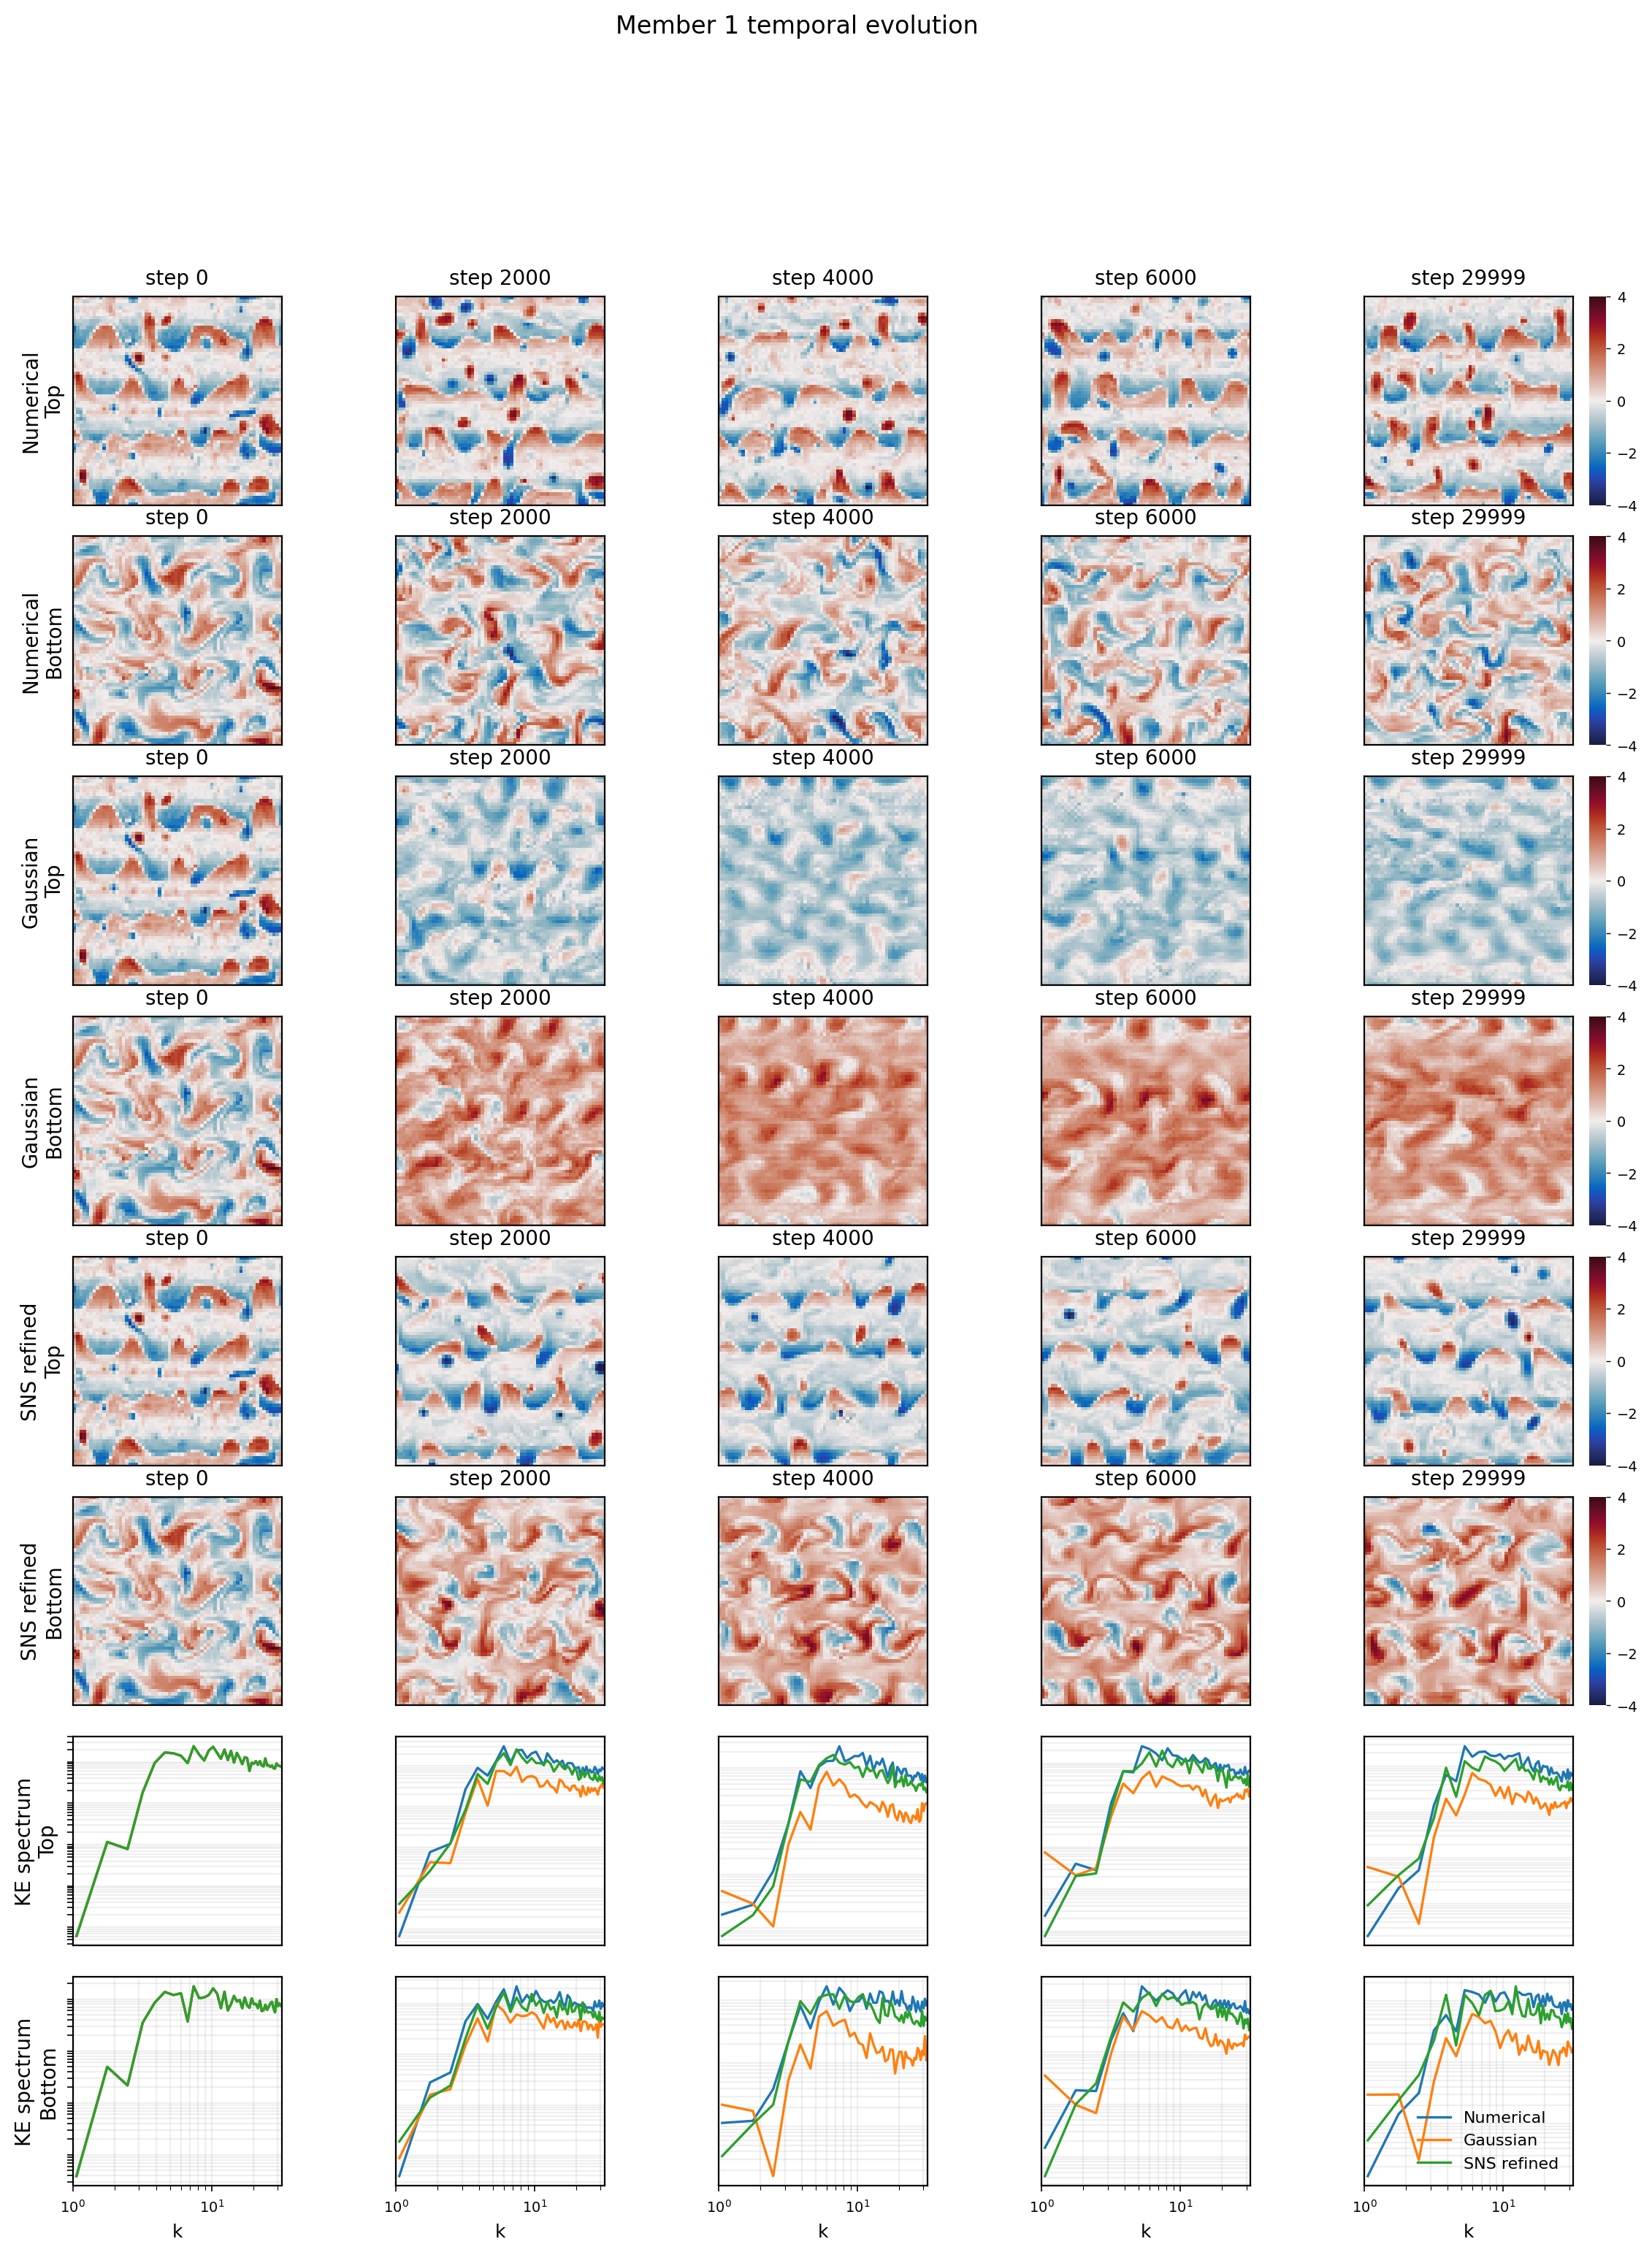

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, LogFormatterMathtext, NullFormatter
import cmocean


def plot_qg_member_temporal_evolution(
    state_vector,                        # [15, T, 2, H, W]
    member_idx=0,
    member_idx_per_method=None,
    steps=(0, 200, 400, 600, 800),
    save_path="qg_member_evolution.png",
    method_names=("Numerical", "Gaussian", "SNS refined"),
    layer_names=("Top", "Bottom"),
    cmap=cmocean.cm.balance,
    interpolation="nearest",
    dpi=200,
    origin="upper",
    field_type="psi",

    # --- spectra controls ---
    Lx=1.0,
    Ly=1.0,
    k_units="cyc",
    spec_logx=True,
    spec_logy=True,
    spec_xlim=(1e-5, 1e-4),
    spec_ylim=None,

    # layout
    hspace=0.15,
    wspace=0.10,
    suptitle=None,

    # NEW: slimmer colorbars
    cbar_width=0.008,      # <- skinnier than before
    cbar_pad=0.008,        # gap from last column
):
    # -------------------------
    # Numpy view
    # -------------------------
    if hasattr(state_vector, "detach"):
        arr = state_vector.detach().cpu().numpy()
    else:
        arr = np.asarray(state_vector)

    B, T, L, H, W = arr.shape

    if member_idx_per_method is None:
        member_idx_per_method = (member_idx, member_idx, member_idx)

    def bidx(m, mem):
        return m * 5 + mem

    def mem_for_method(m):
        return member_idx_per_method[m]

    steps = tuple(s for s in steps if 0 <= s < T)
    ncols = len(steps)
    nrows = 8

    # -------------------------
    # Spectrum prep
    # -------------------------
    dx, dy = Lx / W, Ly / H
    kx = np.fft.fftfreq(W, d=dx)
    ky = np.fft.fftfreq(H, d=dy)
    if k_units == "rad":
        kx *= 2 * np.pi
        ky *= 2 * np.pi

    KX, KY = np.meshgrid(kx, ky, indexing="xy")
    K2 = KX**2 + KY**2
    K = np.sqrt(K2)

    nbins = max(H, W)
    edges = np.linspace(0.0, float(K.max()), nbins + 1)
    centers = 0.5 * (edges[:-1] + edges[1:])
    bin_idx = np.digitize(K, edges) - 1
    valid = (K > 0) & (bin_idx >= 0) & (bin_idx < nbins)

    def ke_spectrum_1d(field_2d):
        fhat = np.fft.fft2(field_2d)
        power = (np.abs(fhat) ** 2) / (H * W) ** 2
        Ek = 0.5 * K2 * power if field_type == "psi" else 0.5 * power / np.where(K2 == 0, np.nan, K2)
        Ebin = np.bincount(bin_idx[valid].ravel(), weights=Ek[valid].ravel(), minlength=nbins)
        return centers, Ebin

    # -------------------------
    # Figure
    # -------------------------
    fig = plt.figure(figsize=(2.6 * ncols + 1.0, 2.1 * nrows), dpi=dpi)
    gs = fig.add_gridspec(nrows, ncols, hspace=hspace, wspace=wspace)

    # -------------------------
    # Image rows (fixed color scale)
    # -------------------------
    vmin, vmax = -4.0, 4.0
    image_axes_lastcol = []

    for r in range(6):
        m, ell = r // 2, r % 2
        mem = mem_for_method(m)

        for c, step in enumerate(steps):
            ax = fig.add_subplot(gs[r, c])
            im = ax.imshow(
                arr[bidx(m, mem), step, ell],
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
                interpolation=interpolation,
                origin=origin,
            )
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_box_aspect(1)
            ax.set_title(f"step {step}", fontsize=10)

            if c == 0:
                ax.set_ylabel(f"{method_names[m]}\n{layer_names[ell]}", fontsize=10)

            if c == ncols - 1:
                image_axes_lastcol.append((ax, im))

    # -------------------------
    # External colorbars (one per image row) - skinnier
    # -------------------------
    for r in range(6):
        ax, im = image_axes_lastcol[r]
        pos = ax.get_position()
        cax = fig.add_axes([pos.x1 + cbar_pad, pos.y0, cbar_width, pos.height])
        cb = fig.colorbar(im, cax=cax)
        cb.set_ticks([-4, -2, 0, 2, 4])
        cb.outline.set_visible(False)
        cb.ax.tick_params(labelsize=7, length=2, width=0.5)

   # -------------------------
    # Spectra rows
    # -------------------------
    for ell in (0, 1):
        row = 6 + ell
        for c, step in enumerate(steps):
            ax = fig.add_subplot(gs[row, c])
            ax.set_box_aspect(1)
            ax.grid(True, which="both", alpha=0.2)
    
            if spec_logx:
                ax.set_xscale("log")
            if spec_logy:
                ax.set_yscale("log")
    
            ax.set_xlim(*spec_xlim)
    
            xmin, xmax = spec_xlim
            for m in range(3):
                mem = mem_for_method(m)
                k, E = ke_spectrum_1d(arr[bidx(m, mem), step, ell])
                mask = (k >= xmin) & (k <= xmax)
                ax.plot(k[mask], E[mask], lw=1.2, label=method_names[m])
    
            if c == 0:
                ax.set_ylabel(f"KE spectrum\n{layer_names[ell]}", fontsize=10)
    
            if ell == 0:
                # second-to-bottom row: NO ticks, NO labels
                ax.set_xticks([])
                ax.set_xticks([], minor=True)
                ax.tick_params(axis="x", which="both", bottom=False, top=False, labelbottom=False)
            else:
                # bottom row: ticks + label "k"
                ax.set_xlabel("k", fontsize=9)
                ax.xaxis.set_major_locator(LogLocator(base=10))
                ax.xaxis.set_major_formatter(LogFormatterMathtext())
                ax.xaxis.set_minor_formatter(NullFormatter())
                ax.tick_params(axis="x", which="major", labelsize=7, length=3, width=0.6)
                ax.tick_params(axis="x", which="minor", length=2, width=0.4)
    
            # y ticks: no labels (as before)
            ax.tick_params(axis="y", which="both", labelleft=False)
            if c == 0:
                ax.tick_params(axis="y", which="both", left=True, length=3, width=0.6)
            else:
                ax.tick_params(axis="y", which="both", left=False)
    
            # legend only once (bottom-right)
            if ell == 1 and c == ncols - 1:
                ax.legend(frameon=False, fontsize=8)

    fig.suptitle(
        suptitle if suptitle else f"Member {member_idx+1} temporal evolution",
        fontsize=12,
        y=0.995,
    )

    fig.savefig(save_path, bbox_inches="tight")
    plt.show()


# -------------------------
# Call (match Numerical 2nd, Gaussian 5th, SNS 5th)
# -------------------------
plot_qg_member_temporal_evolution(
    tensor,
    member_idx=0,
    member_idx_per_method=(1, 4, 4),  # 2,5,5
    steps=(0, 2000, 4000, 6000, tensor.shape[1] - 1),
    spec_xlim=(1, 32),
    k_units="cyc",
)


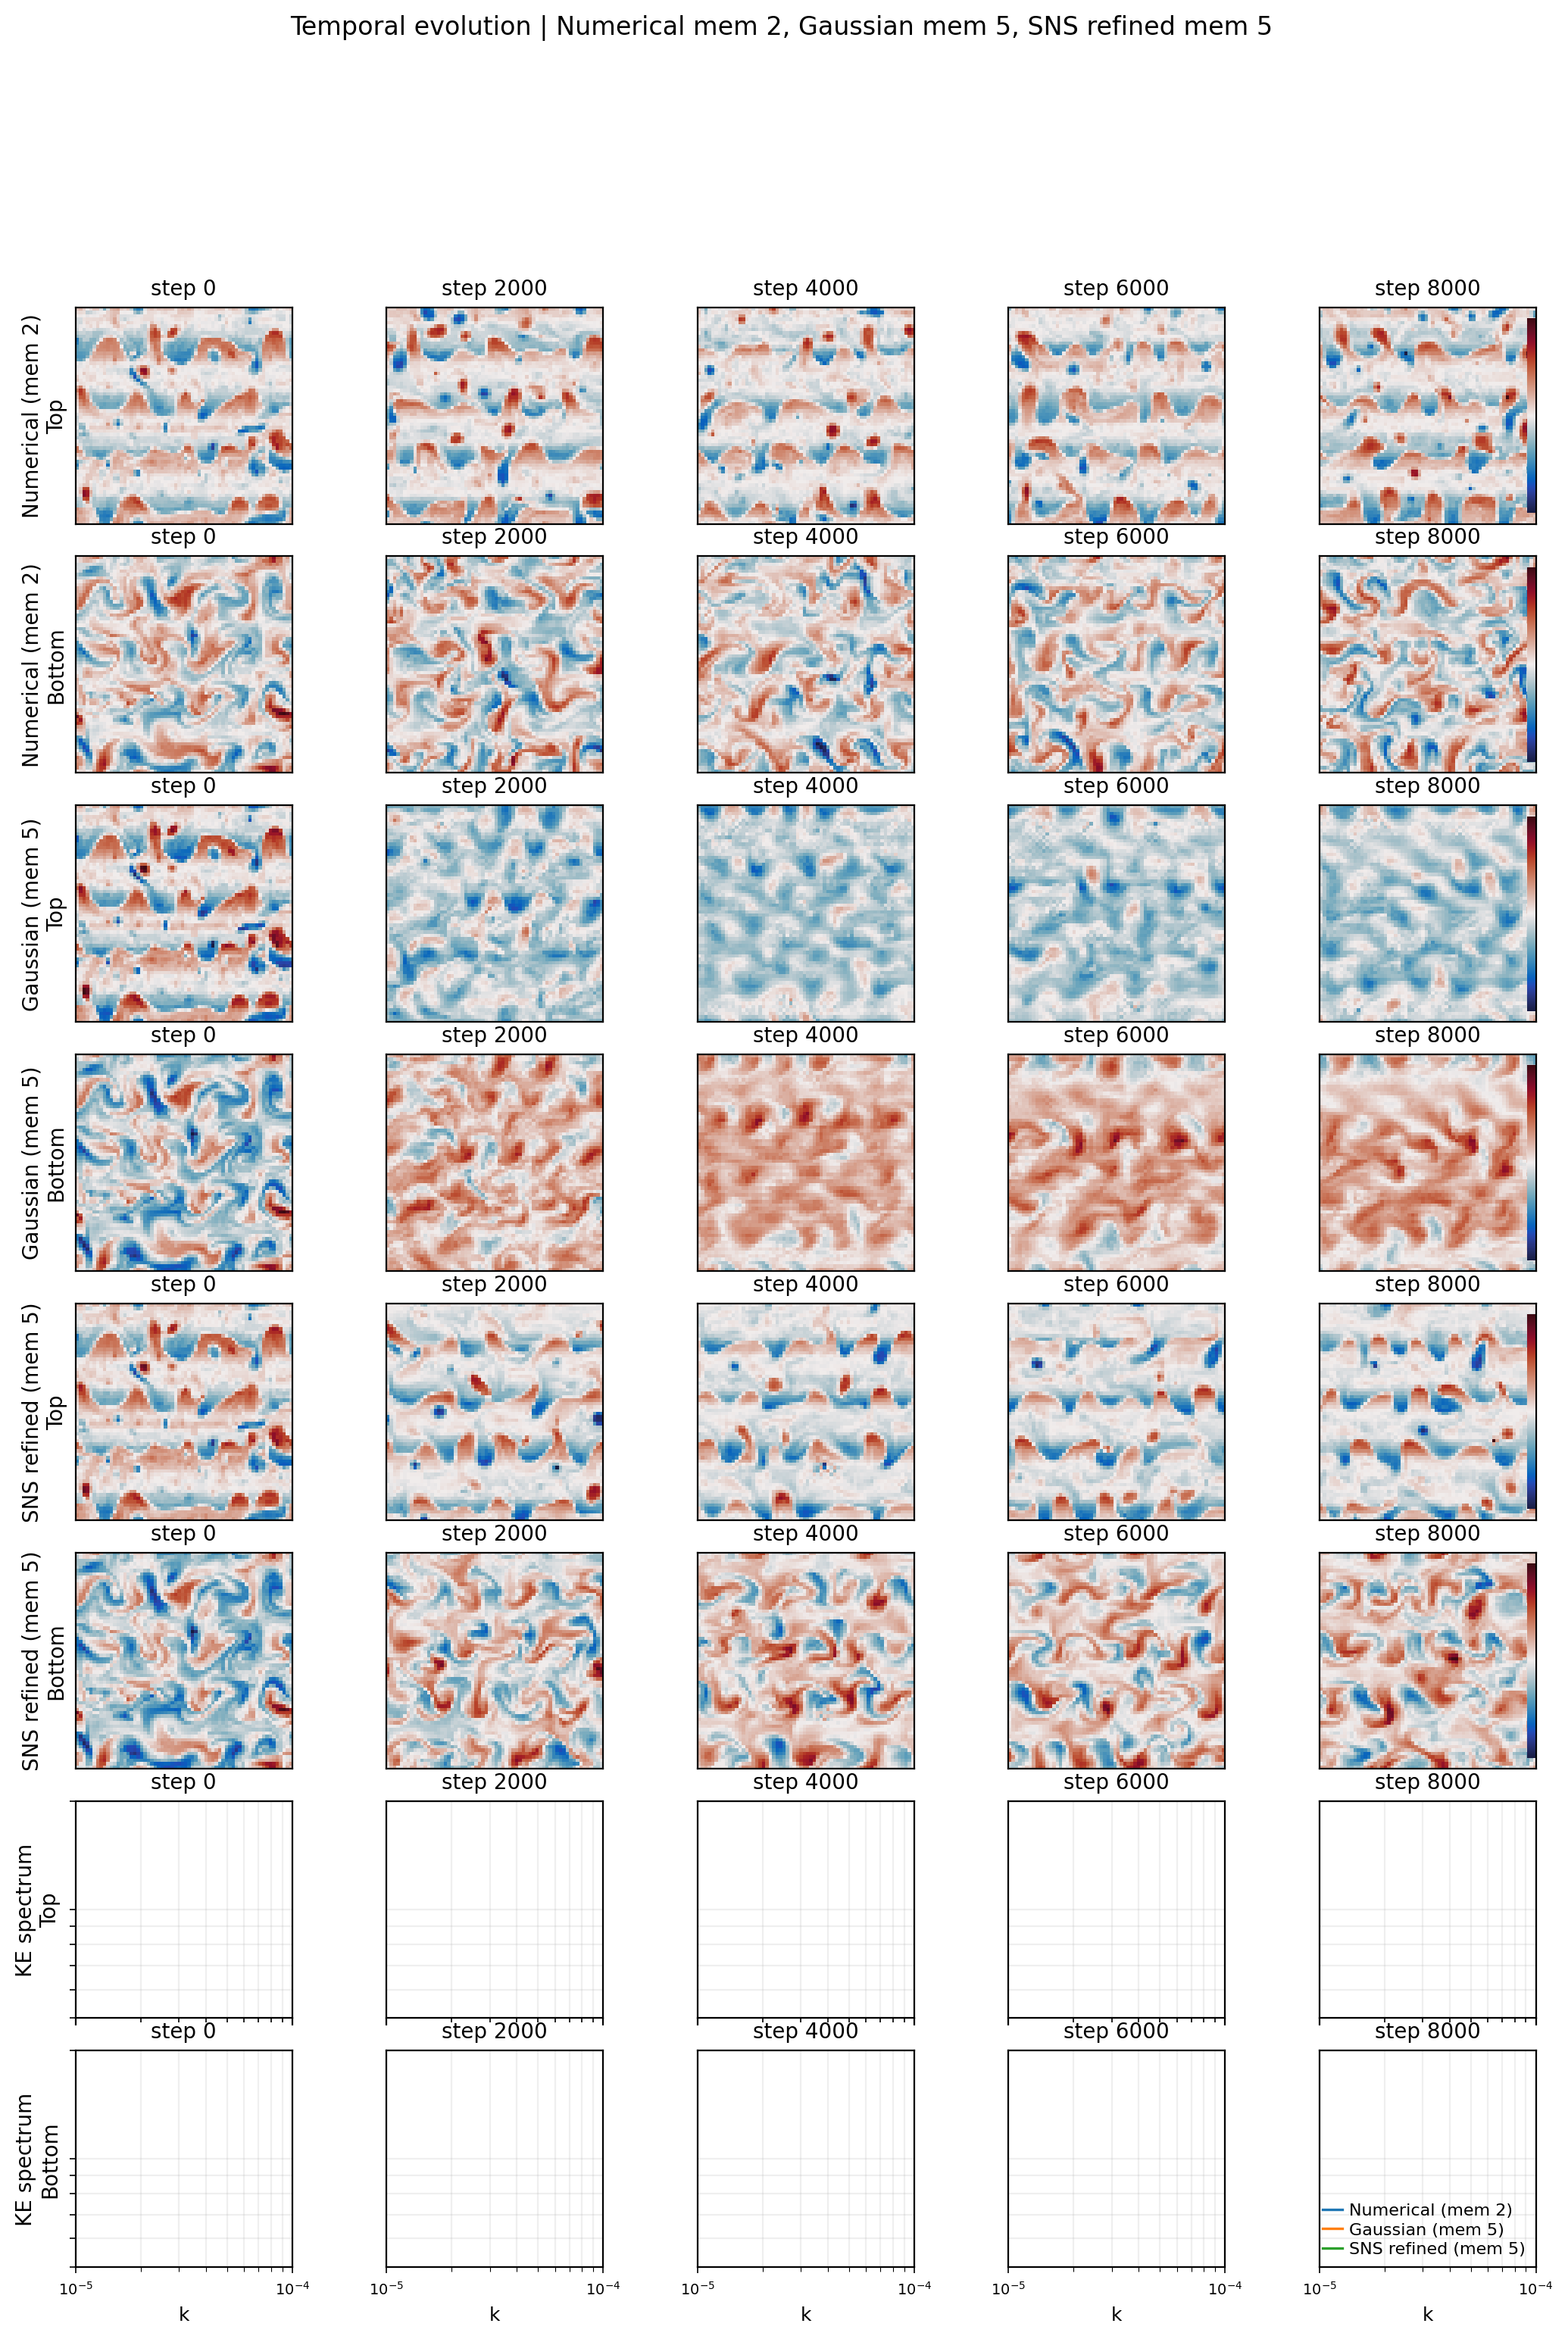

Saved: qg_match_num2_gauss5_snss5.png


In [5]:
plot_qg_member_temporal_evolution(
    tensor,
    member_idx=0,
    steps=(0, 100, 200, 400, 800),
    spec_xlim=(1, 32),      # <-- key change
    k_units="cyc",
)
